# 彩色图像转换为灰度图像

彩色图像转换为灰度图像是图像处理中的一个常见操作。灰度图像只包含亮度信息，而不包含颜色信息，因此它的每个像素值表示的是亮度的强度。

原始图像形状: (3, 3, 3)
灰度图像形状: (3, 3)
像素位置 (2, 1) 的 R, G, B 值: (64, 128, 192)
转换后该像素的灰度值: 116


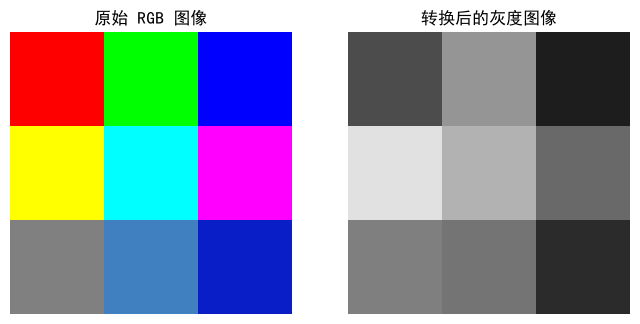

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置matplot中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 构造一个简单的 RGB 彩色图像
img = np.array([
    [[255, 0, 0], [0, 255, 0], [0, 0, 255]],
    [[255, 255, 0], [0, 255, 255], [255, 0, 255]],
    [[128, 128, 128], [64, 128, 192], [10, 30, 200]]
], dtype=np.uint8)

# RGB 转灰度
gray = (0.299 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]).astype(np.uint8)

# 输出图像变化
print("原始图像形状:", img.shape)
print("灰度图像形状:", gray.shape)

# 选取一个像素位置并输出其 RGB 和灰度值
pixel_coord = (2, 1)  # 第三行第二列
r, g, b = img[pixel_coord]
gray_value = gray[pixel_coord]
print(f"像素位置 {pixel_coord} 的 R, G, B 值: ({r}, {g}, {b})")
print(f"转换后该像素的灰度值: {gray_value}")

# 显示原图和灰度图
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img)
axes[0].set_title("原始 RGB 图像")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("转换后的灰度图像")
axes[1].axis("off")

plt.show()

可见，RGB图像转灰度图像的公式为：

$Gray = 0.299 \times R + 0.587 \times G + 0.114 \times B$

即：

```
Gray = 0.299 * R + 0.587 * G + 0.114 * B
```

使用`OpenCV`库可以很方便地将彩色图像转换为灰度图像。下面是一个示例代码：

原始图像形状: (3, 3, 3)
OpenCV 转换后的灰度图像形状: (3, 3)
像素位置 (2, 1) 的 R, G, B 值: (64, 128, 192)
OpenCV 转换后该像素的灰度值: 116


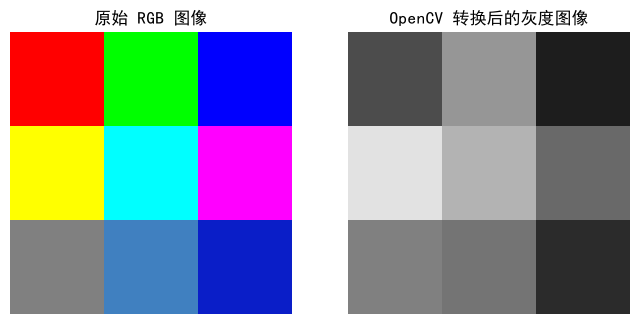

In [2]:
import cv2

gray_cv = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

print("原始图像形状:", img.shape)
print("OpenCV 转换后的灰度图像形状:", gray_cv.shape)

pixel_coord = (2, 1)
r, g, b = img[pixel_coord]
gray_value = gray_cv[pixel_coord]
print(f"像素位置 {pixel_coord} 的 R, G, B 值: ({r}, {g}, {b})")
print(f"OpenCV 转换后该像素的灰度值: {gray_value}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img)
axes[0].set_title("原始 RGB 图像")
axes[0].axis("off")

axes[1].imshow(gray_cv, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("OpenCV 转换后的灰度图像")
axes[1].axis("off")

plt.show()

有时候，图像的灰度值可能使用浮点数表示，这时可以使用`cv2.cvtColor`函数将彩色图像转换为灰度图像，并将结果转换为浮点数类型。

原始图像 dtype: float32 值域: 0.0 1.0
OpenCV 转换后灰度图像 dtype: float32 值域: 0.114 0.88600004
像素位置 (2, 1) 的 R, G, B 值（浮点数）: (0.251, 0.502, 0.753)
OpenCV 转换后该像素的灰度值（浮点数）: 0.456


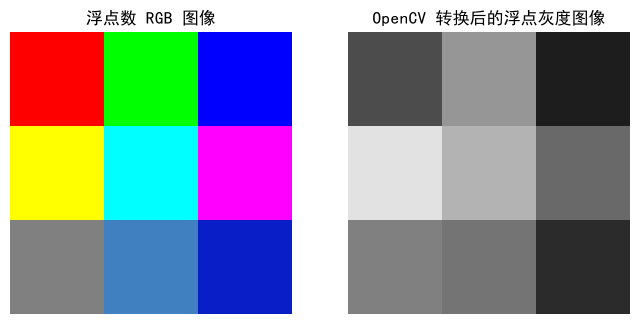

In [3]:
# 将示例图像转换为浮点数模式
img_float = img.astype(np.float32) / 255.0

# 使用 OpenCV 将浮点图像转换为灰度图像
gray_float_cv = cv2.cvtColor(img_float, cv2.COLOR_RGB2GRAY)

print("原始图像 dtype:", img_float.dtype, "值域:", img_float.min(), img_float.max())
print("OpenCV 转换后灰度图像 dtype:", gray_float_cv.dtype, "值域:", gray_float_cv.min(), gray_float_cv.max())

pixel_coord = (2, 1)
r, g, b = img_float[pixel_coord]
gray_value = gray_float_cv[pixel_coord]
print(f"像素位置 {pixel_coord} 的 R, G, B 值（浮点数）: ({r:.3f}, {g:.3f}, {b:.3f})")
print(f"OpenCV 转换后该像素的灰度值（浮点数）: {gray_value:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_float)
axes[0].set_title("浮点数 RGB 图像")
axes[0].axis("off")

axes[1].imshow(gray_float_cv, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("OpenCV 转换后的浮点灰度图像")
axes[1].axis("off")

plt.show()